In [ ]:
fimport pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
sns.set(style="whitegrid", context="notebook")
output_dir = '/content'
print(f"All CSVs will be output to: {output_dir}")

All CSVs will be output to: /content


If running on Colab, completion takes about 50 seconds.

# PartA
Halfway through writing the report, I realized that my logic for deletion/modification and execution strategy could be put into comments, markdown cells, and print statements.

Count before filtering: 23748
Count after filtering: 23405


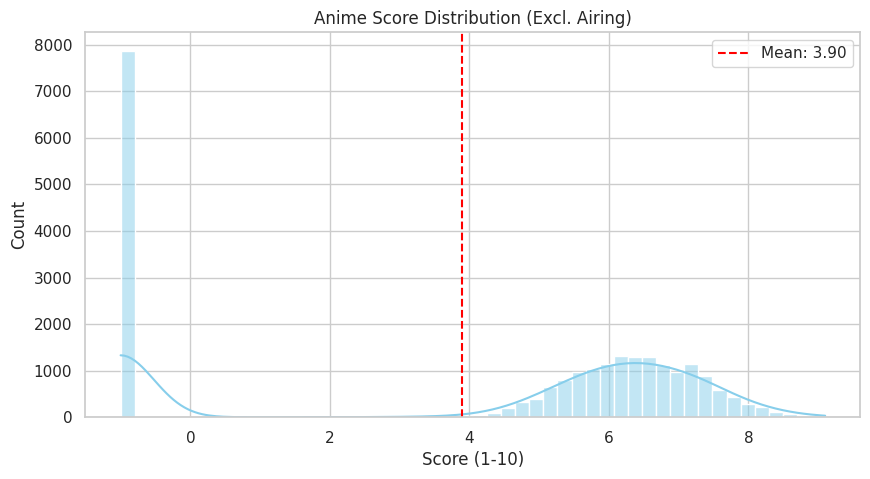

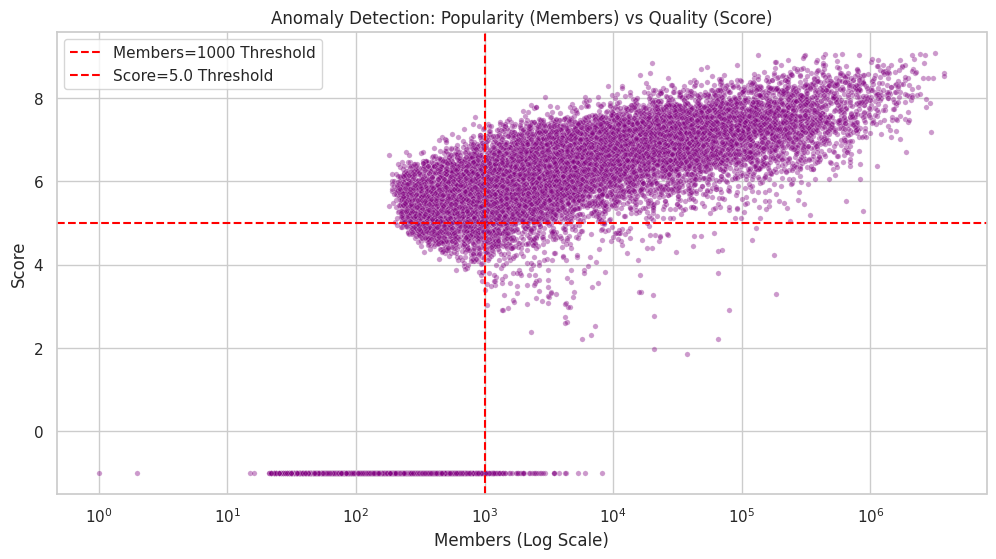

Anime data saved to: /content/anime_cleaned_no_airing.csv


In [ ]:
# PART 1: Anime Data Processing
# ==============================================================================
df_anime = pd.read_csv('anime-transformed-dataset-2023.csv')

# Remove 'currently airing' related anime
print(f"Count before filtering: {len(df_anime)}")
df_anime_clean = df_anime[~df_anime['status'].astype(str).str.lower().str.contains('currently')].copy()

# Drop status column
df_anime_clean = df_anime_clean.drop(columns=['status'])
print(f"Count after filtering: {len(df_anime_clean)}")

# Score Distribution Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df_anime_clean['score'], bins=50, kde=True, color='skyblue')
plt.title('Anime Score Distribution (Excl. Airing)')
plt.xlabel('Score (1-10)')
plt.ylabel('Count')
plt.axvline(x=df_anime_clean['score'].mean(), color='red', linestyle='--', label=f"Mean: {df_anime_clean['score'].mean():.2f}")
plt.legend()
plt.show()

# "Double Low" Detection Scatter Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='members', y='score', data=df_anime_clean, alpha=0.4, s=15, color='purple')
plt.xscale('log')
plt.axvline(x=1000, color='red', linestyle='--', label='Members=1000 Threshold')
plt.axhline(y=5.0, color='red', linestyle='--', label='Score=5.0 Threshold')
plt.title('Anomaly Detection: Popularity (Members) vs Quality (Score)')
plt.xlabel('Members (Log Scale)')
plt.ylabel('Score')
plt.legend()
plt.show()

# Remove outliers
df_anime_clean['score'] = pd.to_numeric(df_anime_clean['score'], errors='coerce')
df_anime_clean = df_anime_clean.dropna(subset=['score'])
df_anime_clean = df_anime_clean[df_anime_clean['score'] > 0]

# Output Anime CSV
anime_output_path = os.path.join(output_dir, 'anime_cleaned_no_airing.csv')
df_anime_clean.to_csv(anime_output_path, index=False)
print(f"Anime data saved to: {anime_output_path}")

As shown in the figure, the scatter plot displays a large number of abnormally low values, similar to the infinite number of unrated users in the original database.

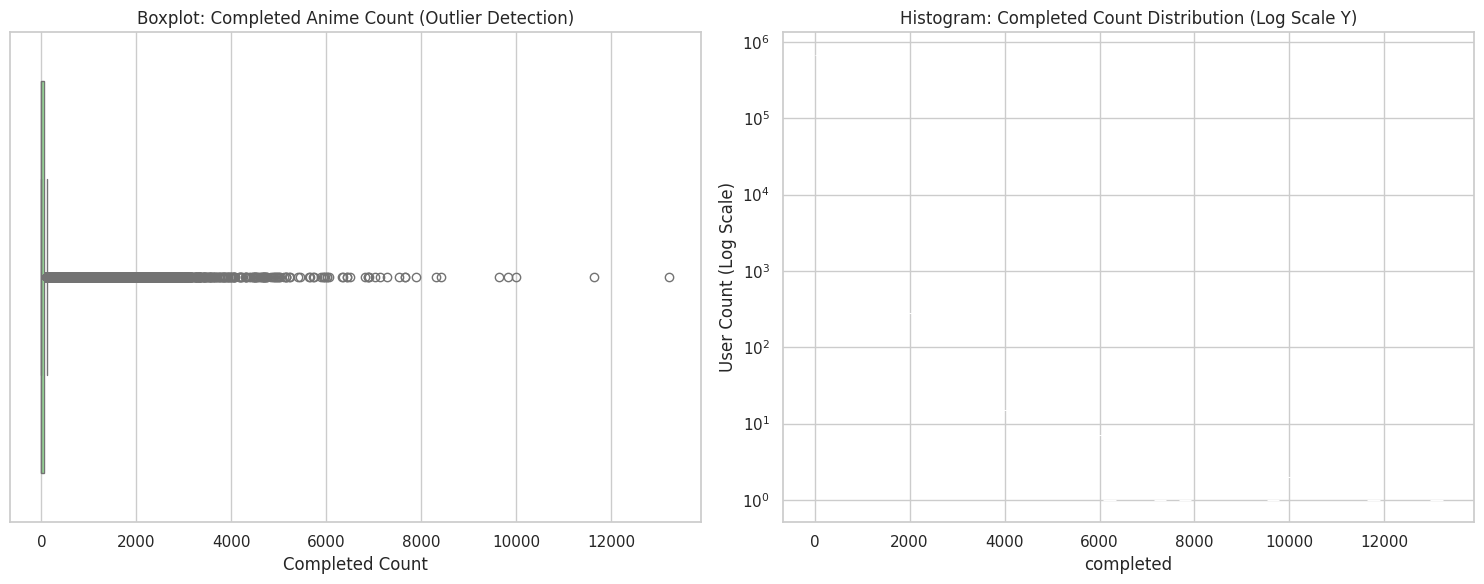

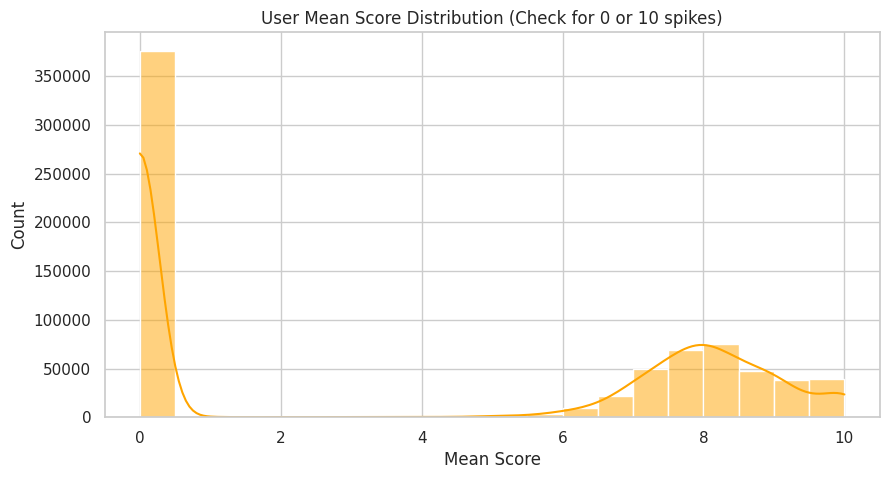

Total user count before cleaning: 731282
Spammers (>1000) = 4847 people
Zombies (Comp=0) = 369391 people
Inactive (Score=0) = 376196 people
User count after cleaning: 295296
Total invalid users removed: 435986 people
User table saved to: /content/users_details_cleaned.csv


In [ ]:
# PART 2: User Details Data Reconnaissance, No Deletion/Modification yet
# ==============================================================================
df_users = pd.read_csv('users-details-transformed-2023.csv')

# Completed Count Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(x=df_users['completed'], ax=axes[0], color='lightgreen')
axes[0].set_title('Boxplot: Completed Anime Count (Outlier Detection)')
axes[0].set_xlabel('Completed Count')

# Histogram
sns.histplot(df_users['completed'], bins=50, ax=axes[1], color='green', log_scale=(False, True)) # Log scale Y-axis, otherwise 0 is too high
axes[1].set_title('Histogram: Completed Count Distribution (Log Scale Y)')
axes[1].set_ylabel('User Count (Log Scale)')

plt.tight_layout()
plt.show()

# Here is the Rating Habit Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_users['mean_score'], bins=20, kde=True, color='orange')
plt.title('User Mean Score Distribution (Check for 0 or 10 spikes)')
plt.xlabel('Mean Score')
plt.show()

# Execute Cleaning
print(f"Total user count before cleaning: {len(df_users)}")

# Three categories of people to delete
mask_spammers = df_users['completed'] > 1000 # Spammers/Bots
mask_zombies  = df_users['completed'] == 0 # Zombies/Dead accounts
mask_inactive = df_users['mean_score'] == 0 # Inactive/Mutes

# See how many die, for record comparison
n_spammers = len(df_users[mask_spammers])
n_zombies = len(df_users[mask_zombies])
n_inactive = len(df_users[mask_inactive])
print(f"Spammers (>300) = {n_spammers} people")
print(f"Zombies (Comp=0) = {n_zombies} people")
print(f"Inactive (Score=0) = {n_inactive} people")

# Execute Deletion
df_users_cleaned = df_users[
    (df_users['completed'] <= 300) &
    (df_users['completed'] > 0) &
    (df_users['mean_score'] > 0)
].copy()

print(f"User count after cleaning: {len(df_users_cleaned)}")
print(f"Total invalid users removed: {len(df_users) - len(df_users_cleaned)} people")

# Save CSV
user_output_path = os.path.join(output_dir, 'users_details_cleaned.csv')
df_users_cleaned.to_csv(user_output_path, index=False)
print(f"User table saved to: {user_output_path}")

As we can see, there are so many zombie accounts and dead users. In the subsequent parts of Part A, specific verification of the data after deletion will be performed.

In [ ]:
# PART 3: Read and Process, User Scores Drop redundant columns + Cascading Cleaning
# ==============================================================================
# Read raw ratings table
df_scores = pd.read_csv('users-scores-transformed-2023.csv')
# Explicitly drop redundant columns (since IDs exist in the other two A-set CSVs, these two columns are unnecessary)
cols_to_drop = ['username', 'anime_title' ]
# Find actually existing columns
existing_cols_to_drop = [c for c in cols_to_drop if c in df_scores.columns]

if existing_cols_to_drop:
    df_scores.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"Drop operation executed, deleted columns: {existing_cols_to_drop}")

# Normalize remaining column names
df_scores.columns = [c.lower().replace(' ', '_') for c in df_scores.columns]

# Similarly remove ratings from "Dead Users"
# A clean table was just created, so it can be called directly
df_users_clean_ref = pd.read_csv(os.path.join(output_dir, 'users_details_cleaned.csv'))
valid_user_ids = set(df_users_clean_ref['id']) # Set of survivor IDs

initial_count = len(df_scores)
# Keep only IDs from the survivor list
df_scores_final = df_scores[df_scores['user_id'].isin(valid_user_ids)]

print(f"Score data cleaning: {initial_count} -> {len(df_scores_final)}")
print(f"Removed {initial_count - len(df_scores_final)} invalid ratings")

# Save CSV
scores_output_path = os.path.join(output_dir, 'users_scores_cleaned.csv')
df_scores_final.to_csv(scores_output_path, index=False)
print(f"Clean ratings table saved to: {scores_output_path}")

Drop operation executed, deleted columns: ['username', 'anime_title']
Score data cleaning: 23796586 -> 13706708
Removed 10089878 invalid ratings
Clean ratings table saved to: /content/users_scores_cleaned.csv


# Part A Re-verification

In [ ]:
# PART 4: Formal EDA - Plotting based on cleaned data
# ==============================================================================
# Verification Phase: Generate comparison charts after cleaning
# Goal: Replicate previous diagnostic charts to prove outliers have completely disappeared

# 1. Read clean CSVs
df_ver_anime = pd.read_csv(os.path.join(output_dir, 'anime_cleaned_no_airing.csv'))
df_ver_users = pd.read_csv(os.path.join(output_dir, 'users_details_cleaned.csv'))

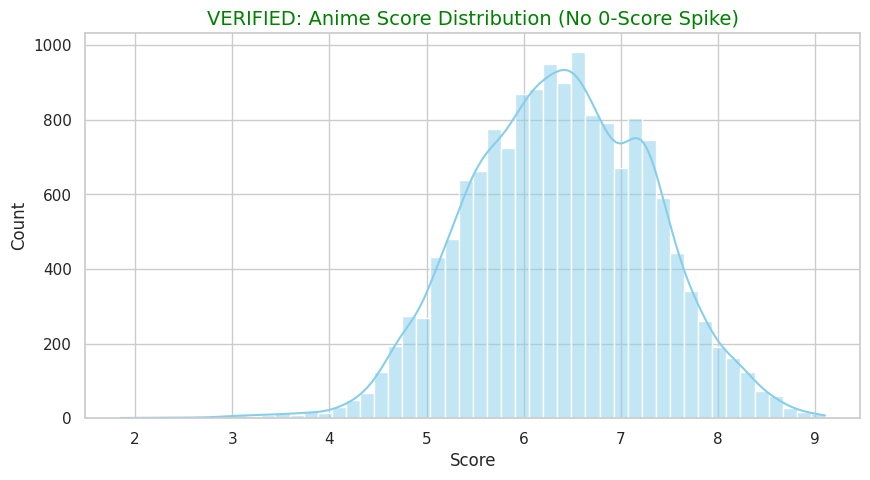

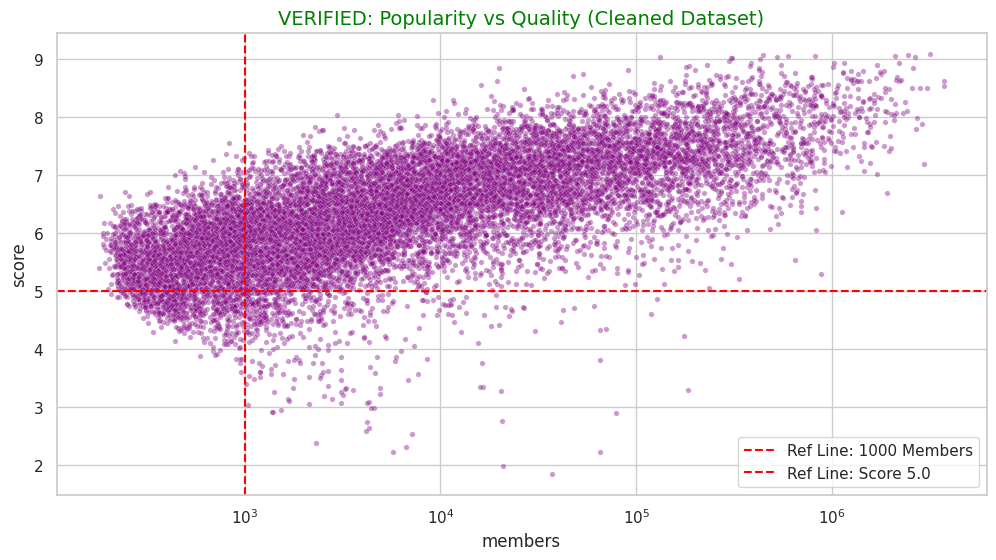

In [ ]:
# Anime Data Health Check

# Score Distribution Histogram
# There is no extra useless data anymore, so data should be normally distributed
plt.figure(figsize=(10, 5))
sns.histplot(df_ver_anime['score'], bins=50, kde=True, color='skyblue')
plt.title('VERIFIED: Anime Score Distribution (No 0-Score Spike)', fontsize=14, color='green')
plt.xlabel('Score')
plt.show()

# Popularity vs Score Scatter Plot
# Although there might still be points in the bottom left, the overall distribution should be cleaner
plt.figure(figsize=(12, 6))
sns.scatterplot(x='members', y='score', data=df_ver_anime, alpha=0.4, s=15, color='purple')
plt.xscale('log')
plt.axvline(x=1000, color='red', linestyle='--', label='Ref Line: 1000 Members')
plt.axhline(y=5.0, color='red', linestyle='--', label='Ref Line: Score 5.0')
plt.title('VERIFIED: Popularity vs Quality (Cleaned Dataset)', fontsize=14, color='green')
plt.legend()
plt.show()

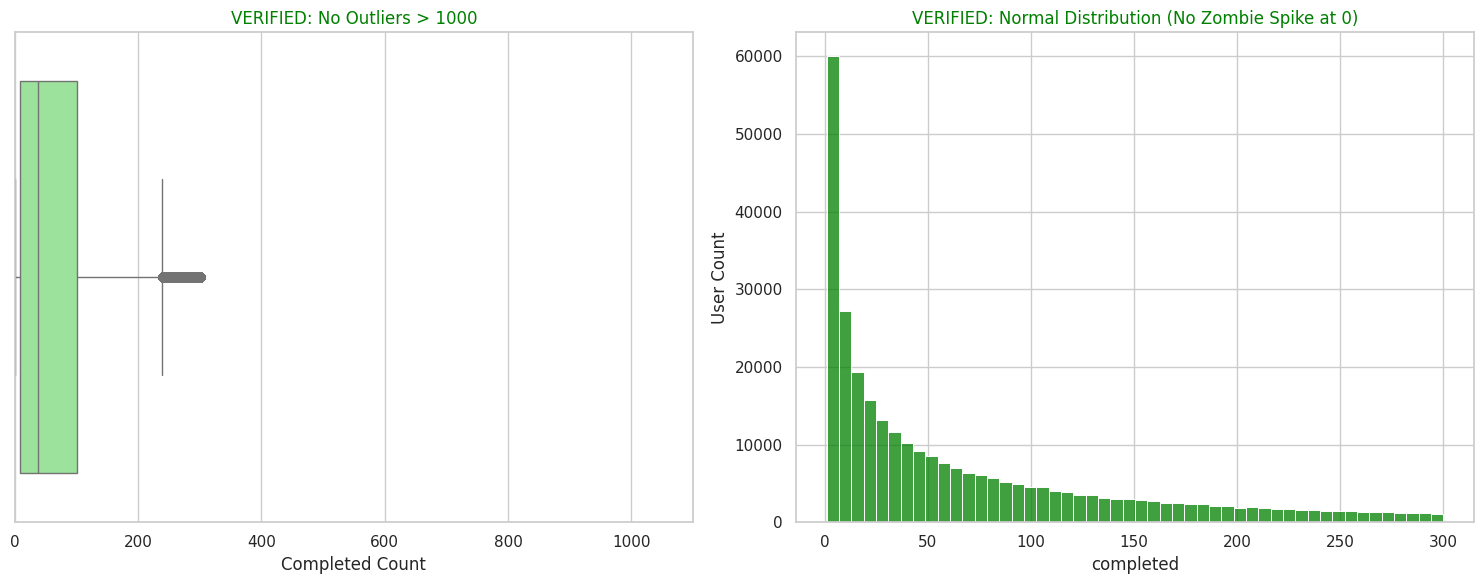

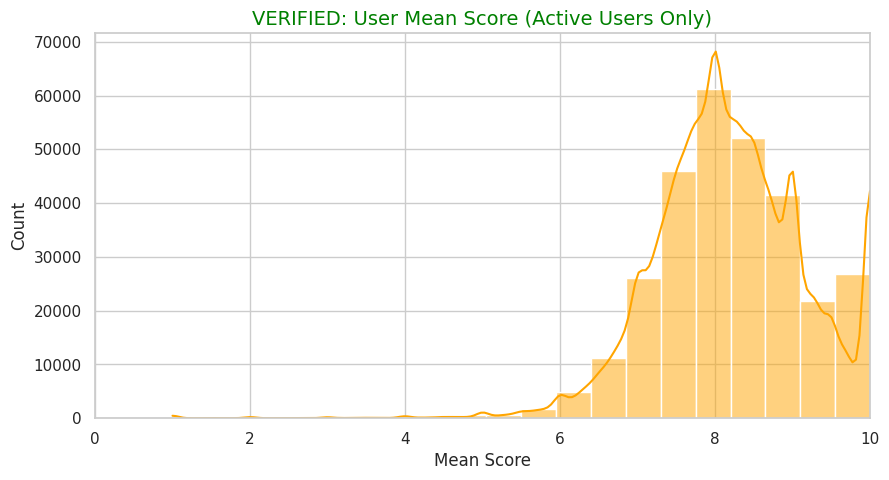

In [ ]:
# User Details Outlier Clearance Check

# Completed Count Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(x=df_ver_users['completed'], ax=axes[0], color='lightgreen')
axes[0].set_title('VERIFIED: No Outliers > 1000', fontsize=12, color='green')
axes[0].set_xlabel('Completed Count')

axes[0].set_xlim(left=0, right=1100)

# Histogram
sns.histplot(df_ver_users['completed'], bins=50, ax=axes[1], color='green')
axes[1].set_title('VERIFIED: Normal Distribution (No Zombie Spike at 0)', fontsize=12, color='green')
axes[1].set_ylabel('User Count')

plt.tight_layout()
plt.show()

# Rating Habit Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_ver_users['mean_score'], bins=20, kde=True, color='orange')
plt.title('VERIFIED: User Mean Score (Active Users Only)', fontsize=14, color='green')
plt.xlabel('Mean Score')
plt.xlim(0, 10)
plt.show()

As expected, the boxplot is normal, and the ratings are no longer distorted. However, it's mysterious that in the plot without 0 scores, it shows that most people, or at least many, have only watched about 10 animes. But anyway, it's not 0, which is already good enough.

# Formal EDA for Part A

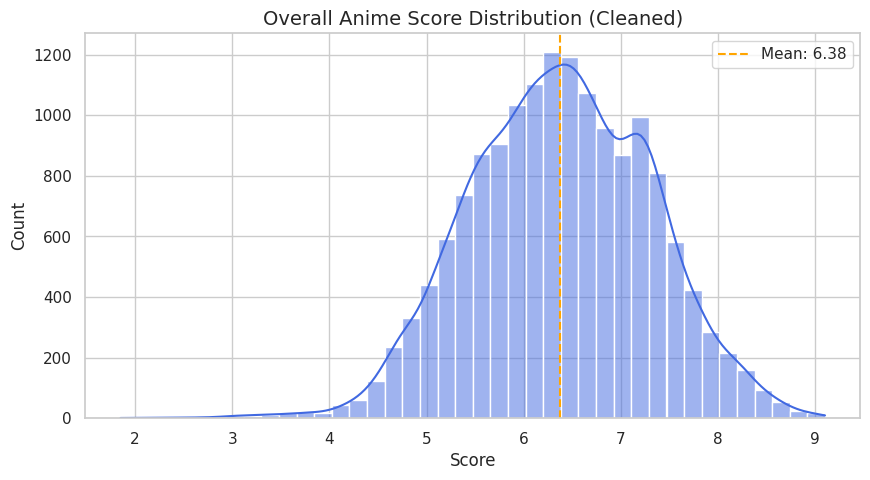

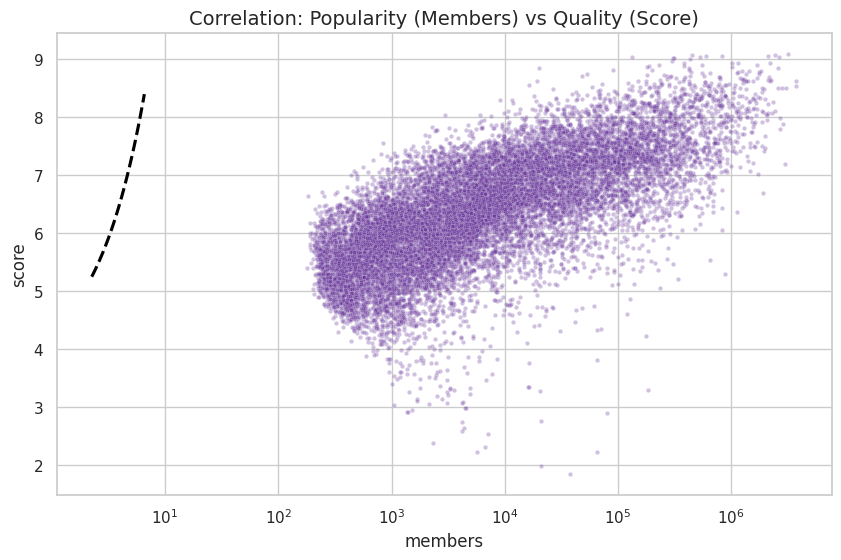

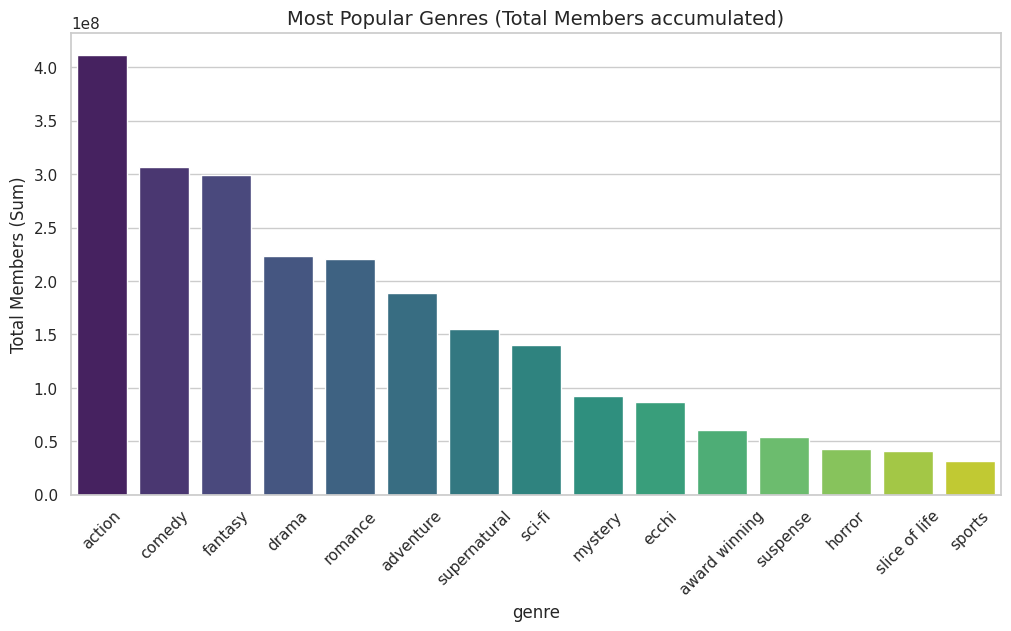

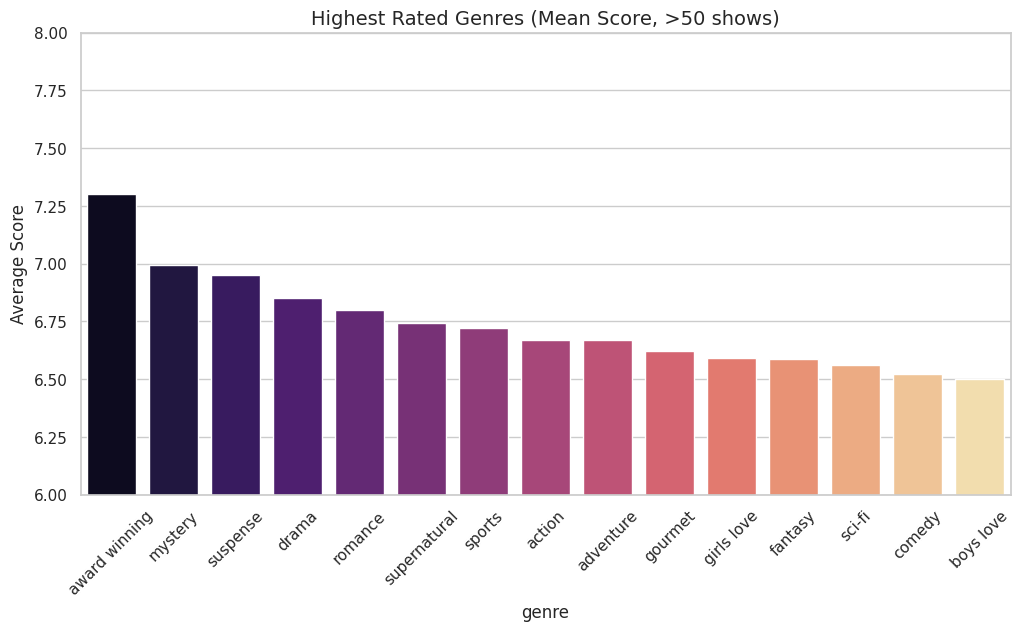

In [ ]:
# PART 5: Anime General Overview and Genre Analysis
# ==============================================================================
# Generate general anime overview and genre analysis charts
# Naturally, reading the cleaned data
df_clean_anime = pd.read_csv(os.path.join(output_dir, 'anime_cleaned_no_airing.csv'))

# Overall Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean_anime['score'], bins=40, kde=True, color='royalblue')
plt.title('Overall Anime Score Distribution (Cleaned)', fontsize=14)
plt.xlabel('Score')
plt.axvline(df_clean_anime['score'].mean(), color='orange', linestyle='--', label=f"Mean: {df_clean_anime['score'].mean():.2f}")
plt.legend()
plt.show()

# Correlation: Popularity vs Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='members', y='score', data=df_clean_anime, alpha=0.3, s=10, color='rebeccapurple')
plt.xscale('log')
plt.title('Correlation: Popularity (Members) vs Quality (Score)', fontsize=14)
plt.xlabel('Members (Log Scale)')
plt.ylabel('Score')

# Add trend line
sns.regplot(x=np.log10(df_clean_anime['members']), y=df_clean_anime['score'], scatter=False, color='black', line_kws={'linestyle':'--'})
plt.show()

# Genre Data Preprocessing
# Exclude data with empty Genre
df_genres_exploded = df_clean_anime.dropna(subset=['genres']).assign(genre=df_clean_anime['genres'].str.split(', ')).explode('genre')

# Most Popular Genres by Total Member accumulation or anime count
genre_popularity = df_genres_exploded.groupby('genre')['members'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_popularity.index, y=genre_popularity.values, hue=genre_popularity.index, legend=False, palette='viridis')
plt.title('Most Popular Genres (Total Members accumulated)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Total Members (Sum)')
plt.show()

# Highest Rated Genres by Mean Score
# Only consider genres with at least 50 animes to prevent extreme cases
genre_counts = df_genres_exploded['genre'].value_counts()
valid_genres = genre_counts[genre_counts > 50].index
genre_quality = df_genres_exploded[df_genres_exploded['genre'].isin(valid_genres)].groupby('genre')['score'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_quality.index, y=genre_quality.values, hue=genre_quality.index, legend=False, palette='magma')
plt.title('Highest Rated Genres (Mean Score, >50 shows)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Average Score')
plt.ylim(6, 8)
plt.show()

Everything looks basically normal. By the way, we could actually use anime count to see which genres are most rampant, or use average popularity to see which genres are hottest, but I haven't done that yet. Back to the charts, I have to say, I'm actually a bit surprised by the highest-rated categories. "Award Winning" is the highest, which is okay, but I didn't expect such a category to exist.

/tmp/ipython-input-2761890025.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


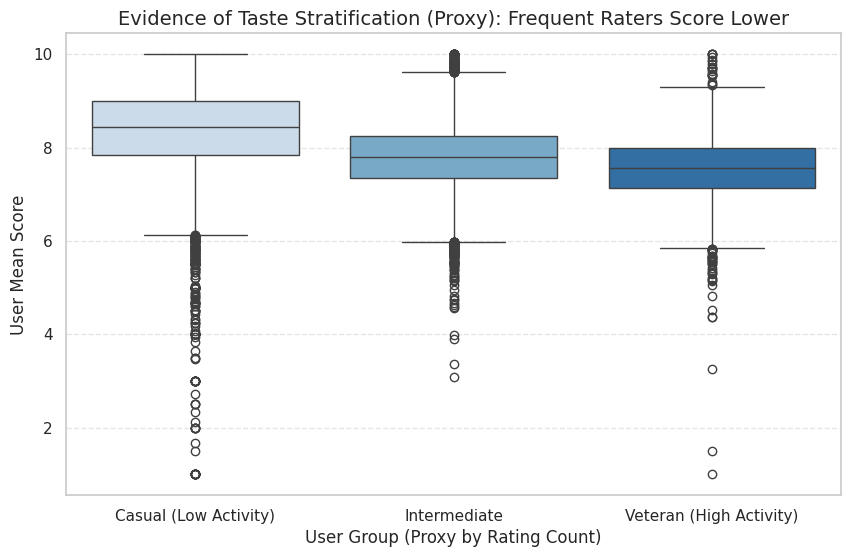

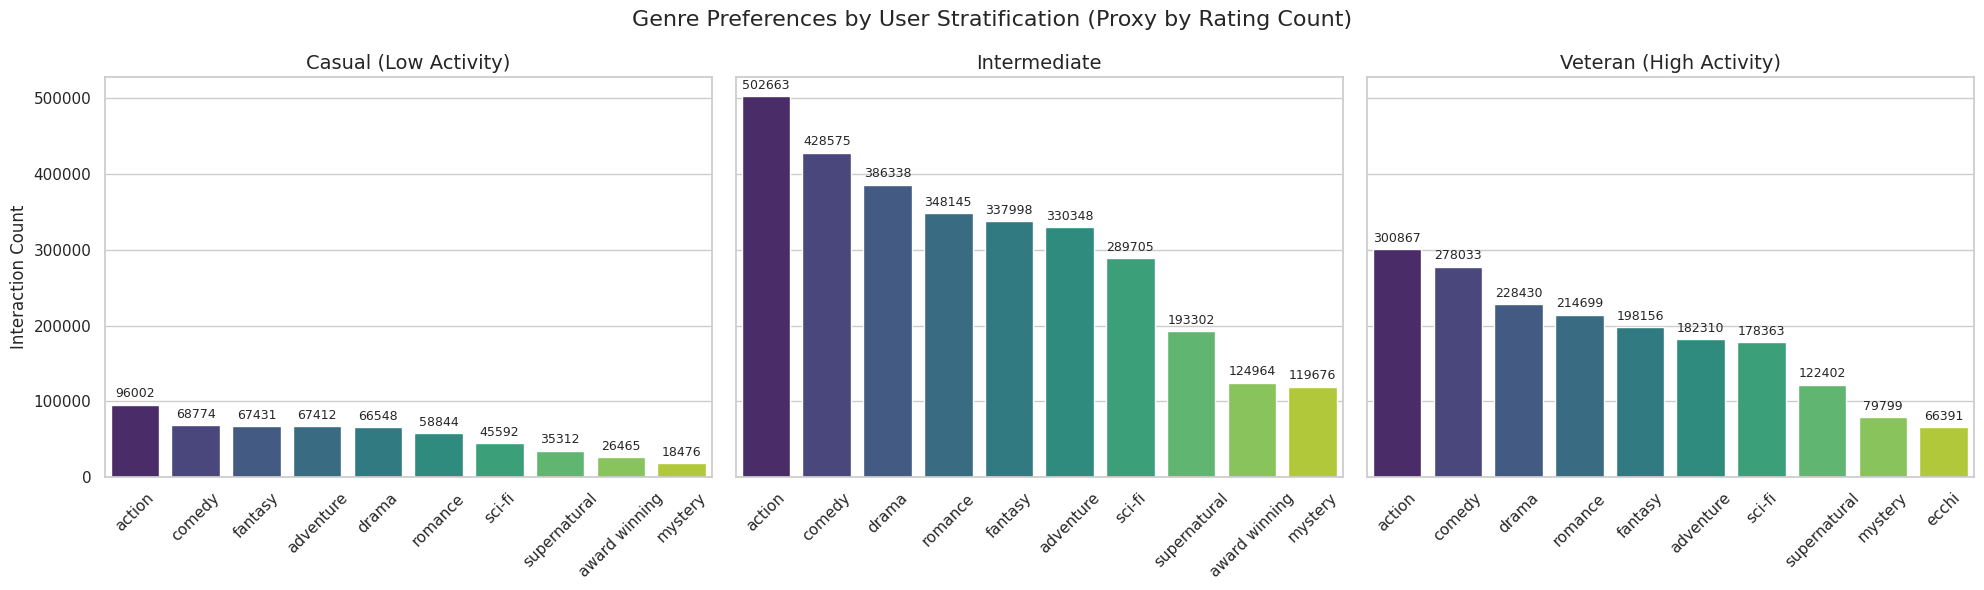

In [ ]:
# PART 6: User Stratification Deep Analysis - Score Distribution and Genre Preferences
# ==============================================================================
df_clean_anime = pd.read_csv(os.path.join(output_dir, 'anime_cleaned_no_airing.csv'))

# Score table (full if possible; if Colab crashes keep nrows like you did)
df_clean_scores = pd.read_csv(os.path.join(output_dir, 'users_scores_cleaned.csv'), nrows=2000000)

# ------------------------------------------------------------------------------
# 1) Build user proxy table from scores: rating_count + mean_score
# ------------------------------------------------------------------------------
user_proxy_2023 = df_clean_scores.groupby('user_id').agg(
    rating_count=('rating', 'count'),
    mean_score=('rating', 'mean')
).reset_index()

# Stratification: Top 10% = Veteran, Bottom 50% = Casual, else Intermediate
q90 = user_proxy_2023['rating_count'].quantile(0.90)
q50 = user_proxy_2023['rating_count'].quantile(0.50)

def get_proxy_tier(cnt):
    if cnt >= q90:
        return 'Veteran (High Activity)'
    elif cnt <= q50:
        return 'Casual (Low Activity)'
    else:
        return 'Intermediate'

user_proxy_2023['Tier'] = user_proxy_2023['rating_count'].apply(get_proxy_tier)
tier_order = ['Casual (Low Activity)', 'Intermediate', 'Veteran (High Activity)']

# ------------------------------------------------------------------------------
# 2) User Mean Score Boxplot (proxy)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Tier', y='mean_score',
    data=user_proxy_2023,
    order=tier_order,
    palette='Blues'
)
plt.title('Evidence of Taste Stratification (Proxy): Frequent Raters Score Lower', fontsize=14)
plt.ylabel('User Mean Score')
plt.xlabel('User Group (Proxy by Rating Count)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# ------------------------------------------------------------------------------
# 3) Genre Preferences by Tier (What do they watch?)
#    Merge Tier -> scores -> anime genres, then explode genres
# ------------------------------------------------------------------------------
anime_genres = df_clean_anime[['id', 'genres']].dropna()

# Merge Tier into score table
merged_df = df_clean_scores.merge(
    user_proxy_2023[['user_id', 'Tier']],
    on='user_id',
    how='inner'
)

# Merge anime genres (avoid id collision by renaming)
anime_genres_renamed = anime_genres.rename(columns={'id': 'anime_id'})
merged_df = merged_df.merge(
    anime_genres_renamed,
    on='anime_id',
    how='inner'
)

# Split and explode genres
merged_exploded = merged_df.assign(
    genre=merged_df['genres'].str.split(', ')
).explode('genre')

# Plot: 3 panels
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, tier in enumerate(tier_order):
    tier_data = merged_exploded[merged_exploded['Tier'] == tier]
    top_tier_genres = tier_data['genre'].value_counts().head(10)

    sns.barplot(
        x=top_tier_genres.index,
        y=top_tier_genres.values,
        ax=axes[i],
        hue=top_tier_genres.index,
        legend=False,
        palette='viridis'
    )

    axes[i].set_title(tier, fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', padding=3, fontsize=9)

axes[0].set_ylabel('Interaction Count')
plt.suptitle('Genre Preferences by User Stratification (Proxy by Rating Count)', fontsize=16)
plt.tight_layout()
plt.show()

The Veteran box is generally lower than the Casual one, with scores decreasing step by step across the three tiers, which matches the expectation that old fans are pickier. The range is roughly from the 8.2 to 7.8 level. As for taste, there isn't much difference, it's almost the same.

# Part B

In [ ]:
# PART B: 2020 Database (Dataset B) - Cleaning and EDA
# ==============================================================================

# Read data
df_anime_b = pd.read_csv('anime.csv')
df_rating_b = pd.read_csv('rating_complete.csv')

# Anime Table Cleaning
initial_b_count = len(df_anime_b)

# 2.1 Column Filtering: Keep only the 7 columns you specified
cols_to_keep_b = ['MAL_ID', 'Name', 'Score', 'Genres', 'Type', 'Episodes', 'Aired']
df_anime_b_clean = df_anime_b[cols_to_keep_b].copy()

# 2.2 Row Filtering: Remove 'Unknown' (including Aired, Score, Episodes)
# Many 'Unknown' values in the 2020 dataset are strings and must be cleaned
mask_valid = (
    (df_anime_b_clean['Score'] != 'Unknown') &
    (df_anime_b_clean['Episodes'] != 'Unknown') &
    (df_anime_b_clean['Aired'] != 'Unknown')
)
df_anime_b_clean = df_anime_b_clean[mask_valid].copy()

# Numerical Normalization
df_anime_b_clean['Score'] = df_anime_b_clean['Score'].astype(float)
df_anime_b_clean['Episodes'] = df_anime_b_clean['Episodes'].astype(int)

# Similar text normalization as Dataset A: lowercase + trim
text_cols = ['Name', 'Genres', 'Type']
for col in text_cols:
    df_anime_b_clean[col] = df_anime_b_clean[col].astype(str).str.lower().str.strip()

print(f"Anime B Cleaning Complete: {initial_b_count} -> {len(df_anime_b_clean)}")
print("Retained columns:", df_anime_b_clean.columns.tolist())

# Output CSV
anime_b_output_path = os.path.join(output_dir, 'anime_b_cleaned.csv')
df_anime_b_clean.to_csv(anime_b_output_path, index=False)
print(f"Anime B saved to: {anime_b_output_path}")

Anime B Cleaning Complete: 17562 -> 12309
Retained columns: ['MAL_ID', 'Name', 'Score', 'Genres', 'Type', 'Episodes', 'Aired']
Anime B saved to: /content/anime_b_cleaned.csv


/tmp/ipython-input-325258606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Score', data=df_anime_b_clean, order=type_order, palette='Set3')


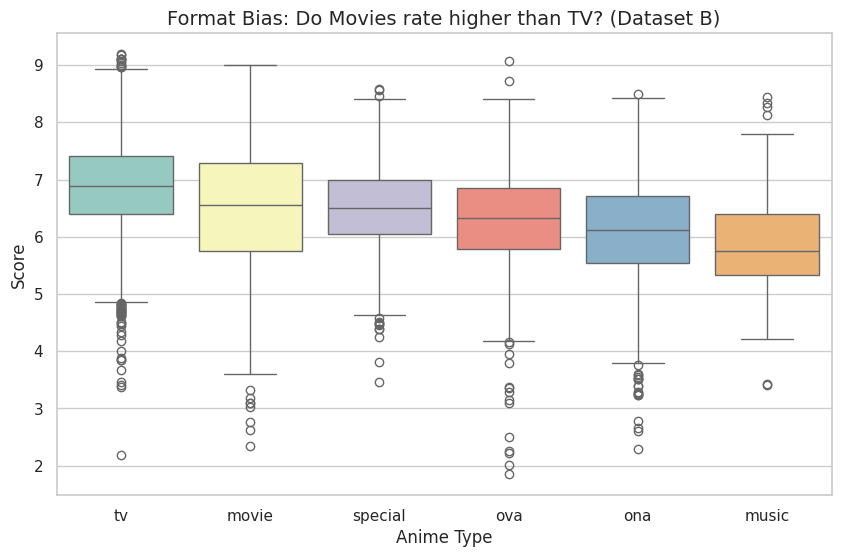

/tmp/ipython-input-325258606.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=b_genres.index, y=b_genres.values, palette='magma')


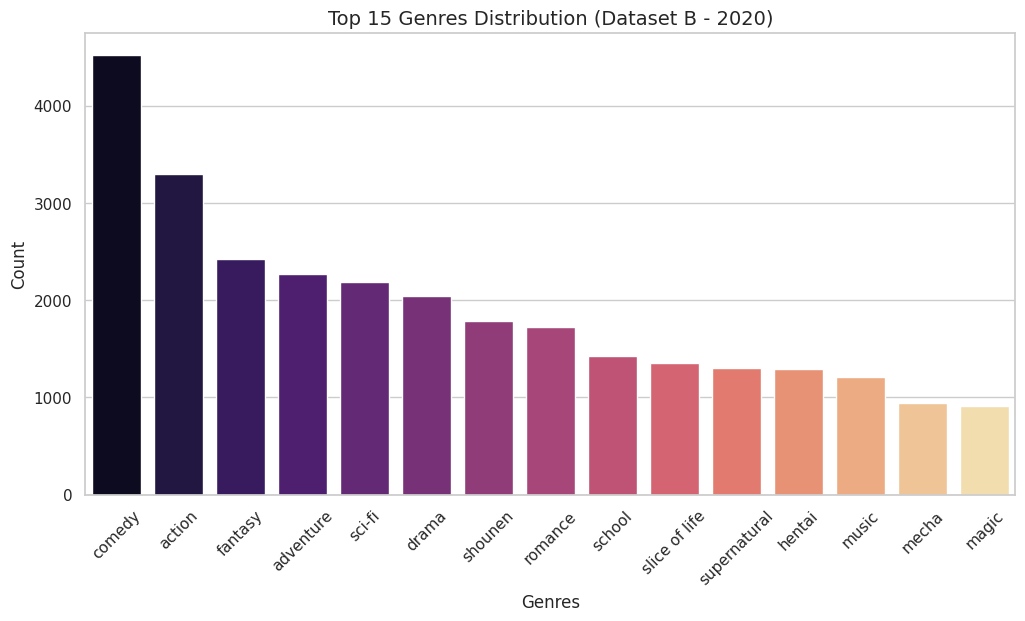

/tmp/ipython-input-325258606.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tier', y='mean_rating', data=user_proxy, order=tier_order_b, palette='Reds')


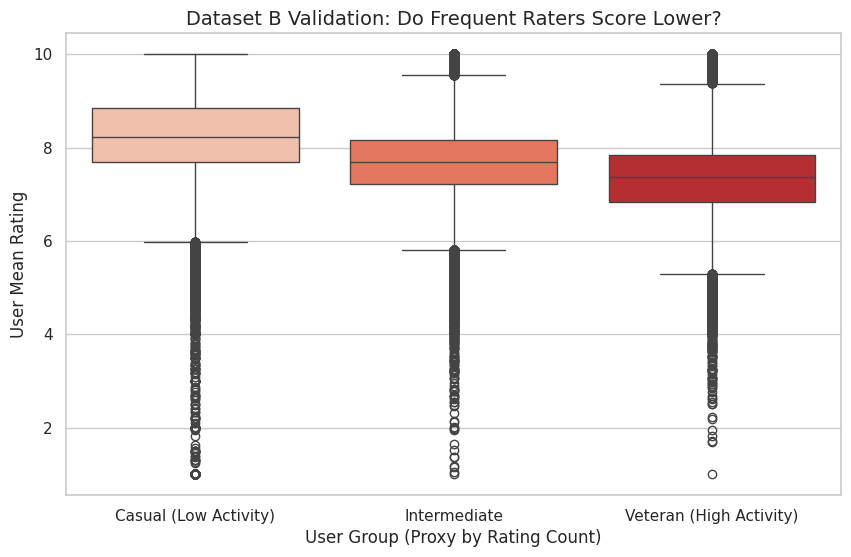

In [ ]:
# PART B - EDA Charts
# ==============================================================================
# Type vs Score Boxplot
plt.figure(figsize=(10, 6))
# Sort by type
type_order = df_anime_b_clean.groupby('Type')['Score'].median().sort_values(ascending=False).index
sns.boxplot(x='Type', y='Score', data=df_anime_b_clean, order=type_order, palette='Set3')
plt.title('Format Bias: Do Movies rate higher than TV? (Dataset B)', fontsize=14)
plt.ylabel('Score')
plt.xlabel('Anime Type')
plt.show()

# Same Genre Distribution
# Mainly to see the difference from 2023
b_genres = df_anime_b_clean['Genres'].str.split(', ').explode().value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=b_genres.index, y=b_genres.values, palette='magma')
plt.title('Top 15 Genres Distribution (Dataset B - 2020)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

# Still User Stratification Control
# But Dataset B has no days_watched, so we use rating_count to replace tenure
# Aggregate to calculate rating count and mean rating for each user
user_proxy = df_rating_b.groupby('user_id').agg(
    rating_count=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()

# Stratification logic
qb90 = user_proxy['rating_count'].quantile(0.90)
qb50 = user_proxy['rating_count'].quantile(0.50)

def get_proxy_tier(cnt):
    if cnt >= qb90: return 'Veteran (High Activity)'
    elif cnt <= qb50: return 'Casual (Low Activity)'
    else: return 'Intermediate'

user_proxy['Tier'] = user_proxy['rating_count'].apply(get_proxy_tier)

plt.figure(figsize=(10, 6))
tier_order_b = ['Casual (Low Activity)', 'Intermediate', 'Veteran (High Activity)']
sns.boxplot(x='Tier', y='mean_rating', data=user_proxy, order=tier_order_b, palette='Reds')
plt.title('Dataset B Validation: Do Frequent Raters Score Lower?', fontsize=14)
plt.xlabel('User Group (Proxy by Rating Count)')
plt.ylabel('User Mean Rating')
plt.show()

Even in the 2020 dataset, the Veteran box position is still lower than the Casual one. We can see that the old folks indeed like to nitpick more. This is indeed a universal situation. However, it seems the scores from the 2023 veterans are generally higher? Is it because the number of elderly users increased, symbolizing that anime has entered a stock market phase? Or has it entered a mid-development stage?